# Introducción a la Visualización de Datos con Matplotlib

<img src='https://imgs.search.brave.com/3vx8NcVfgU3TaX7WHdMQvAkw0OfkcpRV5QdJkUOgCy8/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9sb2dv/LnN2Z2Nkbi5jb20v/bC9tYXRwbG90bGli/LnN2Zw' width=680 />


## ¿Qué es Matplotlib?
Matplotlib es una biblioteca integral para crear visualizaciones estáticas, animadas e interactivas en Python. Es la base de muchas otras herramientas de visualización como Seaborn.

### Usos típicos:
- Exploración de datos (EDA).
- Generación de gráficos para publicaciones científicas.
- Visualización de resultados de modelos de Machine Learning.
- Creación de dashboards personalizados.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
import pandas as pd

# Estilo clásico para gráficos
# plt.style.use('classic')

# Vemos la versión de matplotlib
print(f"Versión de Matplotlib: {mpl.__version__}")

Versión de Matplotlib: 3.10.0


## 1. Conceptos Básicos y Subplots

Matplotlib ofrece dos formas principales de trabajar:
1. **Estilo MATLAB (Procedural)**: Usando `plt.subplot()`.
2. **Estilo Orientado a Objetos (OO)**: Usando `fig, ax = plt.subplots()`.

### Ejemplo Estilo MATLAB

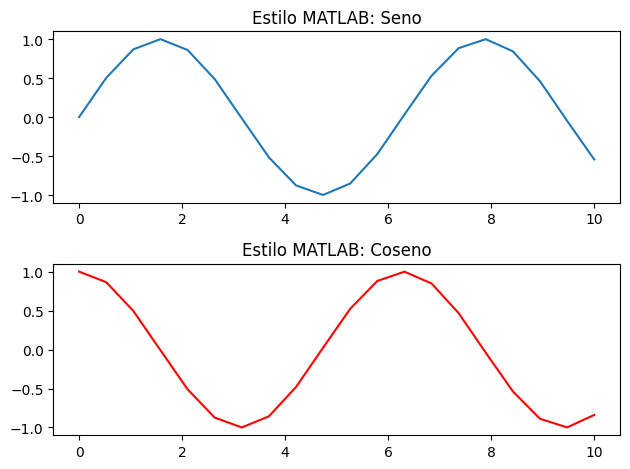

In [4]:
# creamos una figura
plt.figure()

x = np.linspace(0, 10, 100)

# creamos el primero de dos paneles
plt.subplot(2, 1, 1) # (filas, columnas, número de panel)
plt.plot(x, np.sin(x))
plt.title('Estilo MATLAB: Seno')

# creamos el segundo panel
plt.subplot(2, 1, 2)
plt.plot(x, np.cos(x), c='r')
plt.title('Estilo MATLAB: Coseno')

plt.tight_layout()
plt.show()

### Ejemplo Estilo Orientado a Objetos (Recomendado)
Es más potente y explícito, especialmente para gráficos complejos.

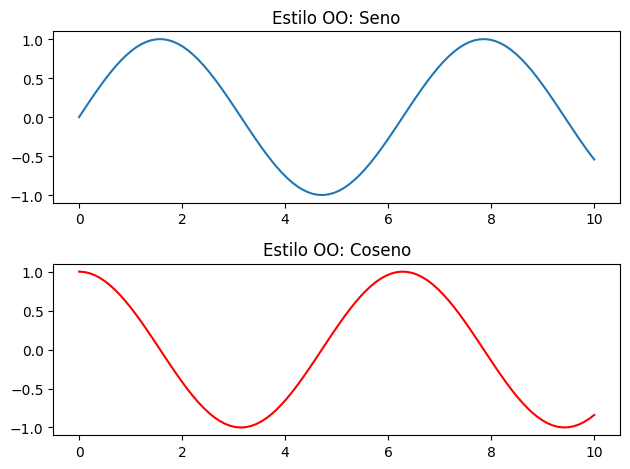

In [5]:
x = np.linspace(0, 10, 100)

# Esto crea la figura (fig), y un array de dos subplots (ax)
fig, ax = plt.subplots(2, sharex=False)

# Llamamos al método plot en cada uno de los axes, para obtener el mismo resultado que en el caso anterior.
ax[0].plot(x, np.sin(x))
ax[0].set_title('Estilo OO: Seno')

ax[1].plot(x, np.cos(x), c='r')
ax[1].set_title('Estilo OO: Coseno')

plt.tight_layout()
plt.show()

## Line Plot (Gráfico de líneas)

Ahora queremos graficar el crecimiento poblacional de dos países

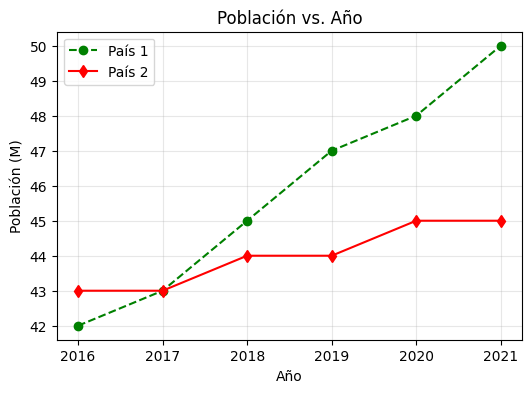

In [11]:
plt.figure(figsize=(6, 4))

x1 = range(2016, 2022)# ¿puedo usar otro objeto acá?
y1 = [42, 43, 45, 47, 48, 50]

x2 = [2016, 2017, 2018, 2019, 2020, 2021]
y2 = [43, 43, 44, 44, 45, 45]

plt.plot(x1, y1, marker='o',  linestyle='--', color='g', label='País 1')
plt.plot(x1, y2,  marker='d', linestyle='-', color='r',  label='País 2')

# plt.yticks([42,44,46,48])
plt.xlabel('Año')
plt.ylabel('Población (M)')
plt.title('Población vs. Año')
plt.legend(loc='upper left')
plt.grid(alpha=.3)
plt.show()


## 2. Trabajando con Datos Reales: Iris Dataset

Vamos a cargar el famoso dataset de flores Iris para nuestros ejemplos.

In [12]:
# Cargamos el dataset Iris usando Seaborn como fuente de datos rápida
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Gráfico de Dispersión (Scatter Plot) por Especie

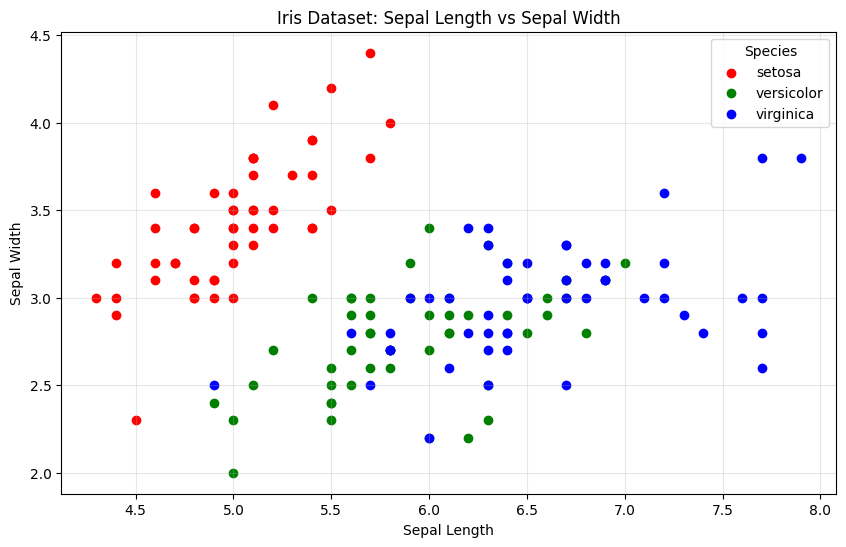

In [34]:
# Configuración del tamaño de la figura
fig = plt.figure(figsize=(10, 6))

# un color por especie
colors = {
    'setosa': 'red',
    'versicolor': 'green',
    'virginica': 'blue'
}

# Creación del scatterplot
for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal_length'], subset['sepal_width'], color=colors[species], label=species)

# Configuración de etiquetas y título
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Iris Dataset: Sepal Length vs Sepal Width')
plt.legend(title='Species')

# Mostrar grilla
plt.grid(alpha=.3)

# Si quisieramos guardar la imagen usamos (siempre antes de plt.show()):
fig.savefig("iris_scatter.png")
plt.show()

### Subplots e Histogramas Iterativos

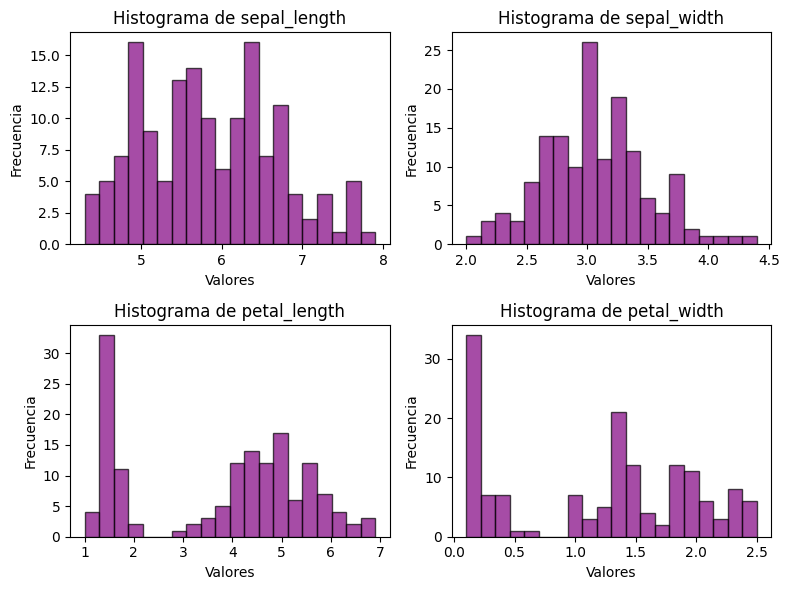

In [22]:
# Seleccionamos las columnas numéricas del DataFrame
columnas = df.select_dtypes(include=[np.number]).columns

# Creamos una figura y ejes para los subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Iteramos sobre las columnas y los ejes para crear los histogramas
for ax, col in zip(axes.flatten(), columnas):
    ax.hist(df[col], bins=20, alpha=0.7, color='purple', edgecolor='black')
    ax.set_title(f'Histograma de {col}')
    ax.set_xlabel('Valores')
    ax.set_ylabel('Frecuencia')

# Ajustamos el layout para que no se solapen los subplots
plt.tight_layout()

# Mostramos la gráfica
plt.show()

## 3. Métodos y Atributos más Usados

### Gráficos de Barras y Pastel

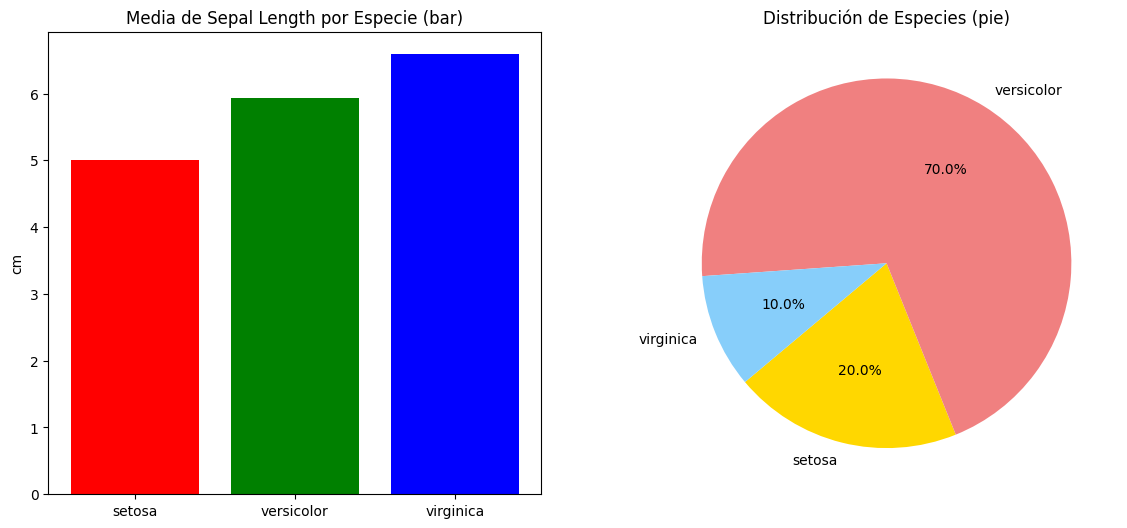

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

media_especies = df.groupby('species')['sepal_length'].mean()

# bar(): Gráfico de barras vertical (o sino, barh)
ax[0].bar(media_especies.index, media_especies.values, color=['red', 'green', 'blue'])
ax[0].set_title('Media de Sepal Length por Especie (bar)')
ax[0].set_ylabel('cm')

# pie(): Gráfico de pastel
conteo_especies = df['species'].value_counts()
# con autopct damos formato de porcentaje, % inicia el formato,  1. => un caracter como mínimo, f => float, %% => mostrar signo porcentaje
ax[1].pie(conteo_especies, labels=conteo_especies.index, autopct='%1.1f%%', startangle=180, colors=['gold', 'lightcoral', 'lightskyblue'])
ax[1].set_title('Distribución de Especies (pie)')

plt.show()

### Gráficos de Cajas (Boxplots)

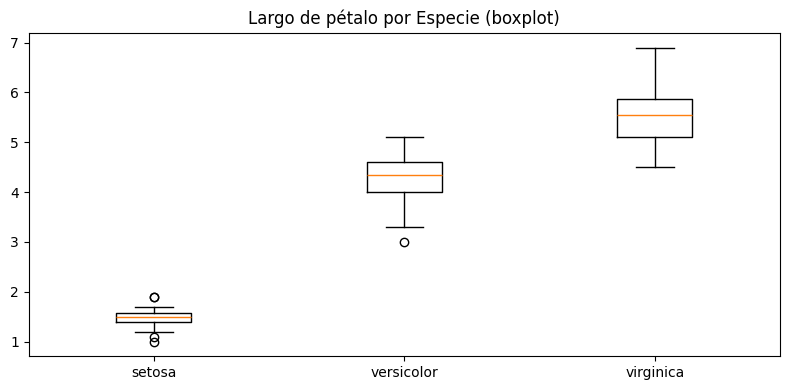

In [33]:
plt.figure(figsize=(8, 4))

# boxplot(): Cajas y bigotes
data_to_plot = [df[df['species'] == s]['petal_length'] for s in df['species'].unique()]
plt.boxplot(data_to_plot, tick_labels=df['species'].unique())
plt.title('Largo de pétalo por Especie (boxplot)')

plt.tight_layout()
plt.show()

## Pairplot con Seaborn

Seaborn crea un grafico de dispersión entre pares de variables y en la diagonal dibuja un histograma o KDE (estimación de densidad por núcleos).
O sea, la distribución de cada variable.

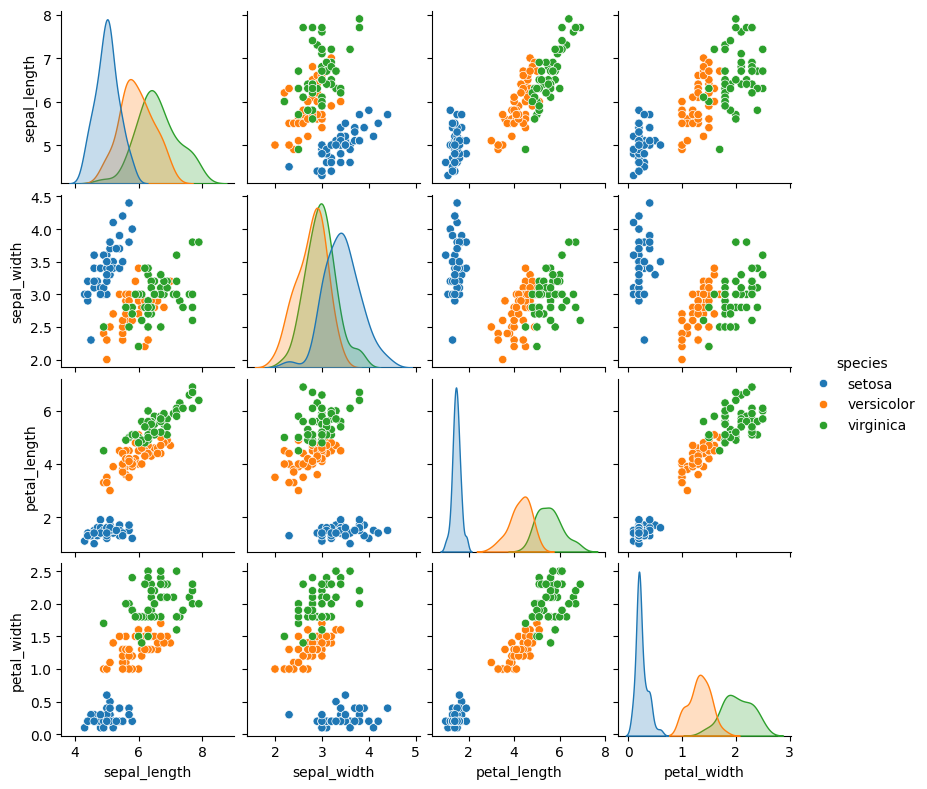

In [35]:
sns.pairplot(df, hue='species', height=2)

### Otros gráficos: Stem, Fill_between, Stackplot

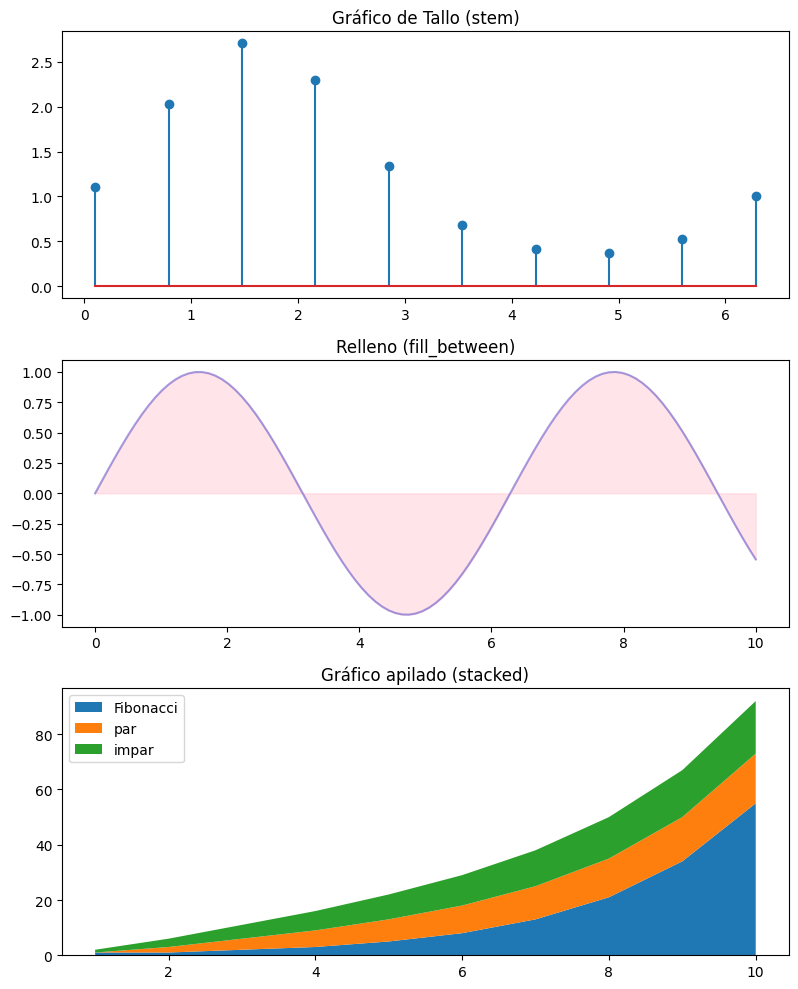

In [40]:
# Creamos una figura de 3 filas, 1 columna
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# --- Datos comunes ---
x = np.linspace(0.1, 2 * np.pi, 10)
y = np.exp(np.sin(x))

# stem(): Gráfico de tallo
axes[0].stem(x, y)
axes[0].set_title('Gráfico de Tallo (stem)')



# fill_between(): Rellenar área entre líneas
x_f = np.linspace(0, 10, 100)
y_f = np.sin(x_f)

# fill_between rellena el área entre y1 y y2 para cada valor de x.
axes[1].fill_between(x_f, y_f, y2=0, color="pink", alpha=0.4)
axes[1].plot(x_f, y_f, color="Slateblue", alpha=0.6)
axes[1].set_title('Relleno (fill_between)')

# stackplot(): Gráfico apilado
x_s = [1,2,3,4,5,6,7,8,9,10]
y1 = [1,1,2,3,5,8,13,21,34,55]
y2 = [0,2,4,6,8,10,12,14,16,18]
y3 = [1,3,5,7,9,11,13,15,17,19]
labels = ['Fibonacci', 'par', 'impar']

axes[2].stackplot(x_s, y1, y2, y3, labels=labels)
axes[2].set_title('Gráfico apilado (stacked)')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 4. Bonus: Plotly Express

Plotly Express es una interfaz de alto nivel para Plotly, diseñada para crear gráficos interactivos de forma extremadamente rápida.

In [42]:
# Gráfico interactivo rápido con Plotly Express
fig = px.scatter(df,
                 x="sepal_width",
                 y="sepal_length",
                 color="species",
                 size='petal_length',
                 hover_data=['petal_width'],
                 template='plotly_dark',
                 title="Interactivo: Iris Sepal Width vs Length")
fig.show()

## En 3D

In [43]:
fig = px.scatter_3d(df,
                    x="sepal_width",
                    y="sepal_length",
                    z="petal_length",
                    color="species",
                    size="petal_width",
                    template='plotly_dark',
                    width=780,
                    title="Iris en 3D")

fig.show()